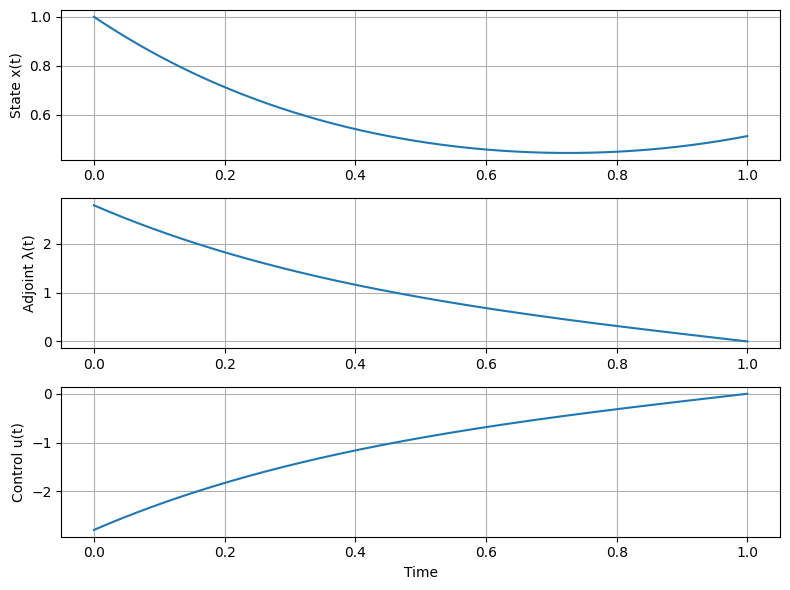

In [5]:
import numpy as np
import matplotlib.pyplot as plt
x0 = 1

delta = 0.001
N = 1000

t = np.linspace(0, 1, N + 1)
h = 1 / N

u_k = np.zeros(N + 1)
x_k = np.zeros(N + 1)
lambda_k = np.zeros(N + 1)

x_k[0] = x0
lambda_k[-1] = 0

converged = -1

while converged < 0:

    u_old = u_k.copy()
    x_old = x_k.copy()
    lambda_old = lambda_k.copy()

    for i in range(N):

        k1 = x_k[i] + u_k[i]

        k2 = (x_k[i] + 0.5 * h * k1) \
             + 0.5 * (u_k[i] + u_k[i+1])

        k3 = (x_k[i] + 0.5 * h * k2) \
             + 0.5 * (u_k[i] + u_k[i+1])

        k4 = (x_k[i] + h * k3) + u_k[i+1]

        x_k[i+1] = x_k[i] + (h / 6) * (k1 + 2*k2 + 2*k3 + k4)

    lambda_k[N] = 0

    for i in range(N):

        j = N - i

        k1 = -3 * x_k[j] - lambda_k[j]

        k2 = -3 * 0.5 * (x_k[j] + x_k[j-1]) \
             - (lambda_k[j] - 0.5 * h * k1)

        k3 = -3 * 0.5 * (x_k[j] + x_k[j-1]) \
             - (lambda_k[j] - 0.5 * h * k2)

        k4 = -3 * x_k[j-1] \
             - (lambda_k[j] - h * k3)

        lambda_k[j-1] = lambda_k[j] \
                        - (h / 6) * (k1 + 2*k2 + 2*k3 + k4)

    u_new = -lambda_k

    u_k = 0.4 * u_new + 0.6 * u_old

    tol_u = delta * np.sum(np.abs(u_k)) \
            - np.sum(np.abs(u_k - u_old))

    tol_x = delta * np.sum(np.abs(x_k)) \
            - np.sum(np.abs(x_k - x_old))

    tol_lambda = delta * np.sum(np.abs(lambda_k)) \
                 - np.sum(np.abs(lambda_k - lambda_old))

    converged = min(tol_u, tol_x, tol_lambda)


plt.figure(figsize=(8, 6))

plt.subplot(3, 1, 1)
plt.plot(t, x_k)
plt.ylabel('State x(t)')
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(t, lambda_k)
plt.ylabel('Adjoint λ(t)')
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(t, u_k)
plt.ylabel('Control u(t)')
plt.xlabel('Time')
plt.grid()

plt.tight_layout()
plt.show()

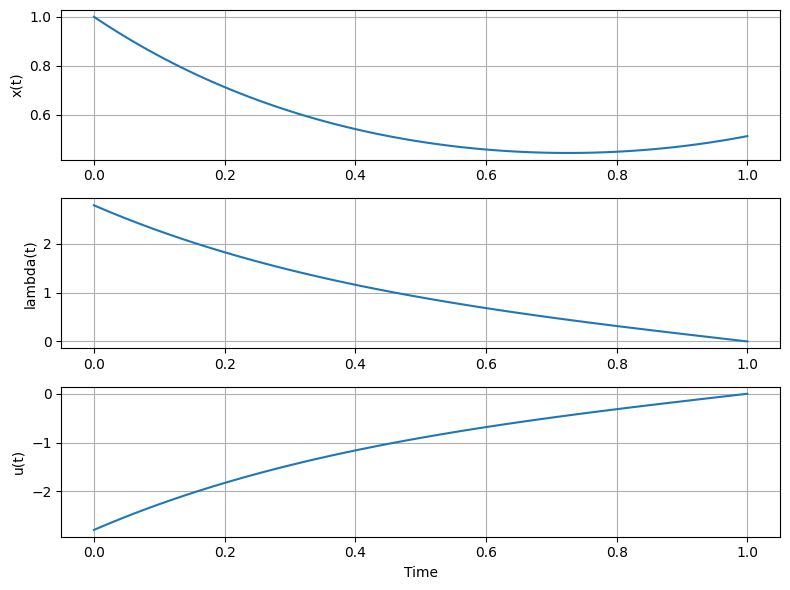

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp

def ode(t, y):

    x = y[0]
    lam = y[1]

    u = -lam

    dxdt = x + u
    dlamdt = -3*x - lam

    return np.vstack((dxdt, dlamdt))

def bc(ya, yb):

    return np.array([
        ya[0] - 1,
        yb[1]
    ])


t = np.linspace(0, 1, 100)

y_guess = np.zeros((2, t.size))

sol = solve_bvp(ode, bc, t, y_guess)

x = sol.y[0]
lam = sol.y[1]
u = -lam

plt.figure(figsize=(8,6))

plt.subplot(3,1,1)
plt.plot(sol.x, x)
plt.ylabel('x(t)')
plt.grid()

plt.subplot(3,1,2)
plt.plot(sol.x, lam)
plt.ylabel('lambda(t)')
plt.grid()

plt.subplot(3,1,3)
plt.plot(sol.x, u)
plt.ylabel('u(t)')
plt.xlabel('Time')
plt.grid()

plt.tight_layout()
plt.show()